# NinaPro DB5 Exercise A 滑动窗口数据准备（简化版）

这个 Notebook 将 10 名受试者的 Exercise A 肌电数据切分为固定长度窗口，并保存为可直接用于 PyTorch 的 NPZ 文件。

- 输入：`S1_E1_A1.mat`～`S10_E1_A1.mat`
- 窗口：200 ms（40 个采样点）可改变
- 步长：100 ms（20 个采样点）可改变
- 训练集：重复 1、3、4、6；测试集：重复 2、5
- 输出形状：`[窗口数, 16 个通道, 40 个时间点]`

数据会先按重复编号划分，再分别生成窗口，避免重叠窗口进入不同集合造成数据泄漏。

## 1. 导入依赖并设置参数

In [2]:
from pathlib import Path
import json
import shutil
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from scipy.io import loadmat


def find_project_root():
    """从当前目录向上查找项目根目录，兼容从项目根目录或 src 目录启动。"""
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / "src").is_dir() and (candidate / "ninapro_data").is_dir():
            return candidate
    raise FileNotFoundError("未找到同时包含 src 和 ninapro_data 的项目根目录。")


PROJECT_ROOT = find_project_root()
RAW_DIR = PROJECT_ROOT / "ninapro_data" / "raw"
ARCHIVE_DIR = RAW_DIR / "archives"
MAT_DIR = RAW_DIR / "exerciseA"
OUTPUT_DIR = PROJECT_ROOT / "ninapro_data" / "processed" / "exerciseA" / "slide_window"

for directory in (ARCHIVE_DIR, MAT_DIR, OUTPUT_DIR):
    directory.mkdir(parents=True, exist_ok=True)

SUBJECT_IDS = range(1, 11)
SAMPLE_RATE = 200
N_CHANNELS = 16
# 滑动窗口大小与步长大小，可根据需要修改
WINDOW_MS = 200
STRIDE_MS = 100
WINDOW_SIZE = SAMPLE_RATE * WINDOW_MS // 1000   # 40 个采样点
STRIDE_SIZE = SAMPLE_RATE * STRIDE_MS // 1000   # 20 个采样点
TRAIN_REPETITIONS = (1, 3, 4, 6)
TEST_REPETITIONS = (2, 5)

GESTURE_NAMES = {
    1: "食指屈曲", 2: "食指伸展",
    3: "中指屈曲", 4: "中指伸展",
    5: "无名指屈曲", 6: "无名指伸展",
    7: "小指屈曲", 8: "小指伸展",
    9: "拇指内收", 10: "拇指外展",
    11: "拇指屈曲", 12: "拇指伸展",
}
# 设置 Matplotlib 中文字体，避免中文乱码
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False

print(f"项目根目录：{PROJECT_ROOT}")
print(f"窗口：{WINDOW_SIZE} 点，步长：{STRIDE_SIZE} 点")
print(f"结果保存目录：{OUTPUT_DIR}")


项目根目录：/root/autodl-tmp/NinaPro
窗口：40 点，步长：20 点
结果保存目录：/root/autodl-tmp/NinaPro/ninapro_data/processed/exerciseA/slide_window


## 2. 准备 Exercise A 原始文件

已存在且有效的 MAT 文件会直接复用；缺少文件时，代码会下载对应受试者的 ZIP，并只解压 Exercise A。

In [3]:
REQUIRED_FIELDS = ("emg", "restimulus", "rerepetition")


def zip_is_valid(path):
    """确认压缩包存在且没有损坏。"""
    try:
        with zipfile.ZipFile(path) as archive:
            return archive.testzip() is None
    except (FileNotFoundError, zipfile.BadZipFile, OSError):
        return False


def mat_is_valid(path):
    """确认 MAT 文件包含后续处理需要的三个字段。"""
    try:
        data = loadmat(path, variable_names=REQUIRED_FIELDS)
        return all(field in data for field in REQUIRED_FIELDS)
    except (FileNotFoundError, OSError, ValueError):
        return False


def download_archive(subject_id):
    """在本地没有有效 ZIP 时，从官方源或备用源下载。"""
    archive_path = ARCHIVE_DIR / f"s{subject_id}.zip"
    if zip_is_valid(archive_path):
        return archive_path

    urls = [
        f"https://ninapro.hevs.ch/files/DB5_Preproc/s{subject_id}.zip",
        f"https://zenodo.org/records/1000116/files/s{subject_id}.zip?download=1",
    ]
    temporary_path = archive_path.with_suffix(".zip.part")
    last_error = None

    for url in urls:
        try:
            print(f"正在下载 S{subject_id}：{url}")
            # 先写入临时文件，避免中断后留下看似完整的 ZIP。
            with requests.get(url, stream=True, timeout=(20, 180)) as response:
                response.raise_for_status()
                with temporary_path.open("wb") as file_handle:
                    for chunk in response.iter_content(1024 * 1024):
                        if chunk:
                            file_handle.write(chunk)
            if not zip_is_valid(temporary_path):
                raise zipfile.BadZipFile("下载的 ZIP 文件不完整。")
            temporary_path.replace(archive_path)
            return archive_path
        except (requests.RequestException, OSError, zipfile.BadZipFile) as error:
            last_error = error
            temporary_path.unlink(missing_ok=True)

    raise RuntimeError(f"S{subject_id} 下载失败：{last_error}")


def prepare_mat_file(subject_id):
    """返回一名受试者的 Exercise A MAT 文件路径。"""
    file_name = f"S{subject_id}_E1_A1.mat"
    mat_path = MAT_DIR / file_name
    if mat_is_valid(mat_path):
        return mat_path

    archive_path = download_archive(subject_id)
    temporary_path = mat_path.with_suffix(".mat.part")
    with zipfile.ZipFile(archive_path) as archive:
        # ZIP 内可能带有子目录，因此只比较文件名。
        members = [name for name in archive.namelist() if Path(name).name.lower() == file_name.lower()]
        if len(members) != 1:
            raise FileNotFoundError(f"{archive_path.name} 中未找到唯一的 {file_name}。")
        with archive.open(members[0]) as source, temporary_path.open("wb") as target:
            shutil.copyfileobj(source, target)

    if not mat_is_valid(temporary_path):
        temporary_path.unlink(missing_ok=True)
        raise ValueError(f"提取的 MAT 文件校验失败：{file_name}")
    temporary_path.replace(mat_path)
    return mat_path


mat_paths = {subject_id: prepare_mat_file(subject_id) for subject_id in SUBJECT_IDS}
print(f"已准备 {len(mat_paths)} 个 Exercise A 文件。")
mat_paths


正在下载 S1：https://ninapro.hevs.ch/files/DB5_Preproc/s1.zip
正在下载 S2：https://ninapro.hevs.ch/files/DB5_Preproc/s2.zip
正在下载 S3：https://ninapro.hevs.ch/files/DB5_Preproc/s3.zip
正在下载 S4：https://ninapro.hevs.ch/files/DB5_Preproc/s4.zip
正在下载 S5：https://ninapro.hevs.ch/files/DB5_Preproc/s5.zip
正在下载 S6：https://ninapro.hevs.ch/files/DB5_Preproc/s6.zip
正在下载 S7：https://ninapro.hevs.ch/files/DB5_Preproc/s7.zip
正在下载 S8：https://ninapro.hevs.ch/files/DB5_Preproc/s8.zip
正在下载 S9：https://ninapro.hevs.ch/files/DB5_Preproc/s9.zip
正在下载 S10：https://ninapro.hevs.ch/files/DB5_Preproc/s10.zip
已准备 10 个 Exercise A 文件。


{1: PosixPath('/root/autodl-tmp/NinaPro/ninapro_data/raw/exerciseA/S1_E1_A1.mat'),
 2: PosixPath('/root/autodl-tmp/NinaPro/ninapro_data/raw/exerciseA/S2_E1_A1.mat'),
 3: PosixPath('/root/autodl-tmp/NinaPro/ninapro_data/raw/exerciseA/S3_E1_A1.mat'),
 4: PosixPath('/root/autodl-tmp/NinaPro/ninapro_data/raw/exerciseA/S4_E1_A1.mat'),
 5: PosixPath('/root/autodl-tmp/NinaPro/ninapro_data/raw/exerciseA/S5_E1_A1.mat'),
 6: PosixPath('/root/autodl-tmp/NinaPro/ninapro_data/raw/exerciseA/S6_E1_A1.mat'),
 7: PosixPath('/root/autodl-tmp/NinaPro/ninapro_data/raw/exerciseA/S7_E1_A1.mat'),
 8: PosixPath('/root/autodl-tmp/NinaPro/ninapro_data/raw/exerciseA/S8_E1_A1.mat'),
 9: PosixPath('/root/autodl-tmp/NinaPro/ninapro_data/raw/exerciseA/S9_E1_A1.mat'),
 10: PosixPath('/root/autodl-tmp/NinaPro/ninapro_data/raw/exerciseA/S10_E1_A1.mat')}

## 3. 读取并检查数据

使用修正后的 `restimulus` 和 `rerepetition`。标签 0 表示静息，只保留标签 1～12、重复 1～6 且 EMG 数值有限的采样点。

In [4]:
def load_subject(subject_id, mat_path):
    """读取一名受试者的数据，并生成有效采样点掩码。"""
    data = loadmat(mat_path, variable_names=REQUIRED_FIELDS)
    emg = np.asarray(data["emg"], dtype=np.float32)
    stimulus = np.asarray(data["restimulus"]).reshape(-1).astype(np.int16)
    repetition = np.asarray(data["rerepetition"]).reshape(-1).astype(np.int8)

    if emg.shape != (len(stimulus), N_CHANNELS) or len(repetition) != len(stimulus):
        raise ValueError(f"S{subject_id} 的数据形状不一致。")

    finite = np.isfinite(emg).all(axis=1)
    active = (stimulus >= 1) & (stimulus <= 12)
    valid_repetition = np.isin(repetition, range(1, 7))
    # 满足三个条件即为有效采样点：有穷、动作类别有效、重复编号有效
    valid = finite & active & valid_repetition

    return {
        "subject_id": subject_id,
        "emg": emg,
        "stimulus": stimulus,
        "repetition": repetition,
        "valid": valid,
    }


records = [load_subject(subject_id, mat_paths[subject_id]) for subject_id in SUBJECT_IDS]
quality_df = pd.DataFrame({
    "受试者": [record["subject_id"] for record in records],
    "总采样点": [len(record["emg"]) for record in records],
    "有效动作采样点": [int(record["valid"].sum()) for record in records],  
    "无效数值行": [int((~np.isfinite(record["emg"]).all(axis=1)).sum()) for record in records],
    "动作类别数": [int(np.unique(record["stimulus"][record["valid"]]).size) for record in records],
    "重复编号数": [int(np.unique(record["repetition"][record["valid"]]).size) for record in records],
})

assert quality_df["动作类别数"].eq(12).all()
assert quality_df["重复编号数"].eq(6).all()
quality_df


,受试者,总采样点,有效动作采样点,无效数值行,动作类别数,重复编号数
0,1,130267,49672,0,12,6
1,2,148367,61941,0,12,6
2,3,131366,48051,0,12,6
3,4,151664,59442,0,12,6
4,5,148526,49799,0,12,6
5,6,151793,63414,0,12,6
6,7,151206,54992,0,12,6
7,8,147802,52783,0,12,6
8,9,148120,52418,0,12,6
9,10,149919,61122,0,12,6


## 4. 找出连续动作区段

窗口只能在同一个动作、同一次重复的连续区段内部生成，不能跨越静息或动作边界。

findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei, SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei, SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei, SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei, SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei, SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei, SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei, SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei, SimHei


findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei, SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei, SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei, SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei, SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei, SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei, SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei, SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei, SimHei
findfont: Generi

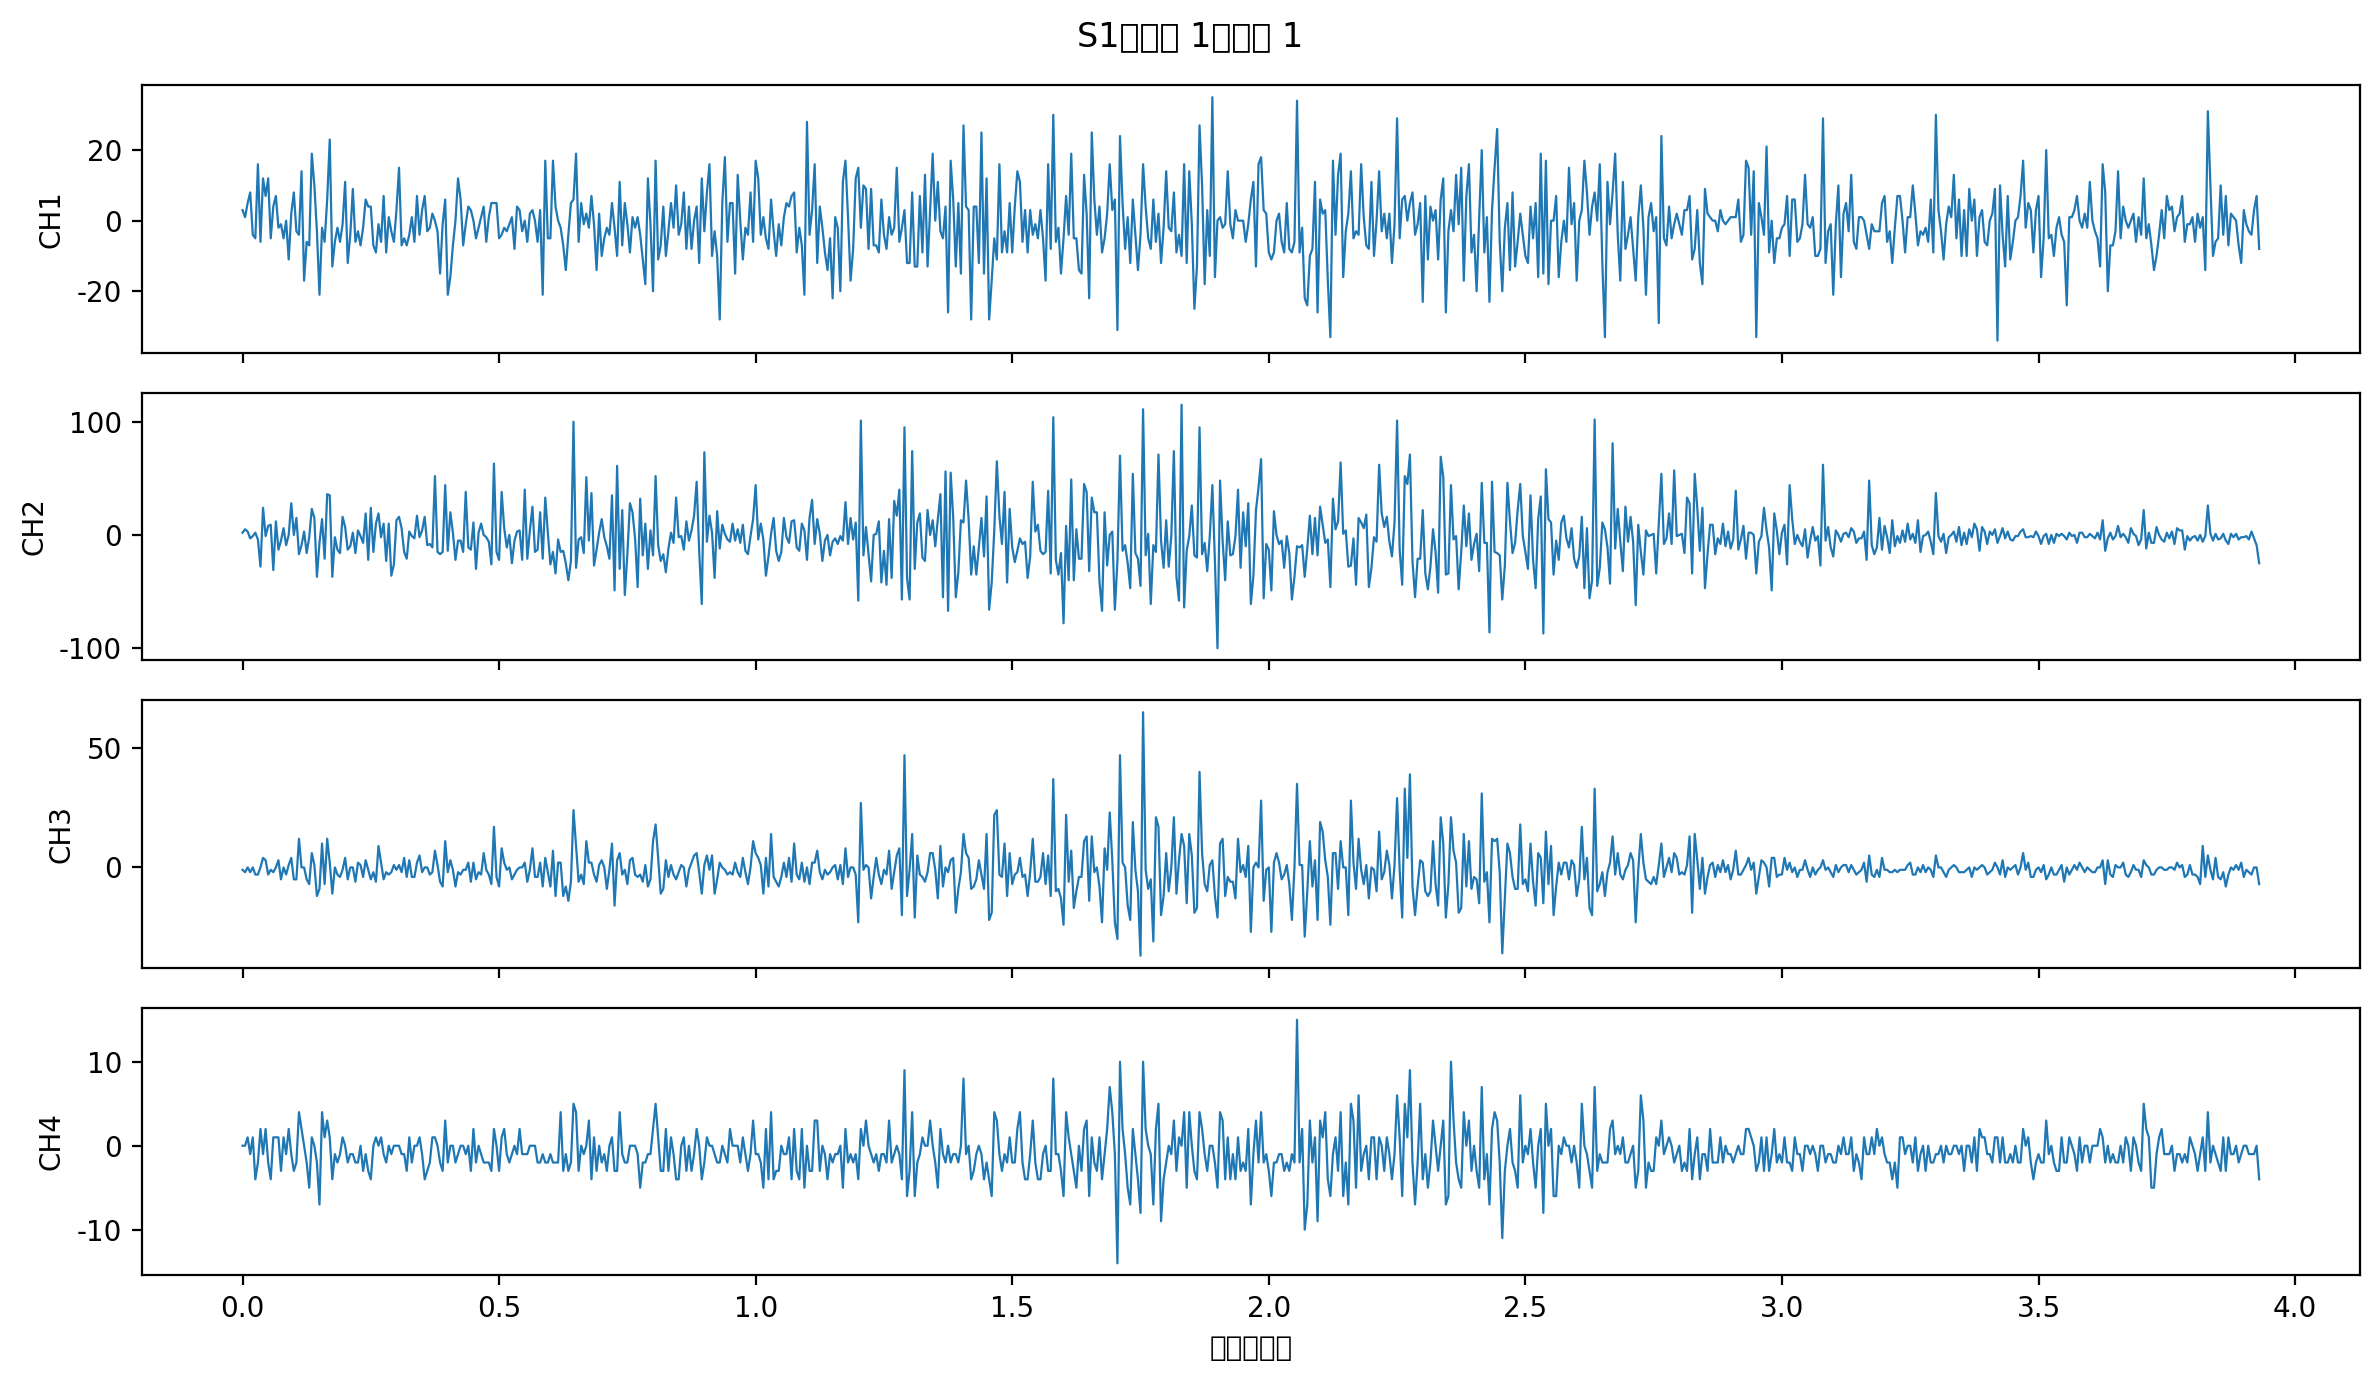

In [5]:
def contiguous_segments(record):
    """依次返回每个有效连续区段的起点、终点、动作和重复编号。"""
    stimulus = record["stimulus"]
    repetition = record["repetition"]
    valid = record["valid"]

    # 有效性、动作标签或重复编号任意一项变化，都表示新片段开始。
    boundary = np.ones(len(stimulus), dtype=bool)
    boundary[1:] = (
        (valid[1:] != valid[:-1])
        | (stimulus[1:] != stimulus[:-1])
        | (repetition[1:] != repetition[:-1])
    )
    starts = np.flatnonzero(boundary)
    ends = np.r_[starts[1:], len(stimulus)]

    for start, end in zip(starts, ends):
        if valid[start]:
            yield int(start), int(end), int(stimulus[start]), int(repetition[start])


# 查看 S1 第一段有效动作的前 4 个通道，确认分段后的信号形态。
example_record = records[0]
example_start, example_end, example_label, example_repetition = next(contiguous_segments(example_record))
example_emg = example_record["emg"][example_start:example_end]
example_time = np.arange(len(example_emg)) / SAMPLE_RATE

fig, axes = plt.subplots(4, 1, figsize=(12, 7), sharex=True, dpi=200)
for channel, axis in enumerate(axes):
    axis.plot(example_time, example_emg[:, channel], linewidth=0.8)
    axis.set_ylabel(f"CH{channel + 1}")
axes[-1].set_xlabel("时间（秒）")
fig.suptitle(f"S1，动作 {example_label}，重复 {example_repetition}")
fig.tight_layout()
plt.show()


## 5. 划分集合并生成滑动窗口

每个窗口先从 `[时间, 通道]` 转置为 `[通道, 时间]`。原始动作编号 1～12 同时转换为模型标签 0～11。

In [6]:
def create_window_datasets(records):
    """先按重复编号选择集合，再在每个连续动作区段内切窗。"""
    buffers = {
        split: {"X": [], "y": [], "subject": [], "repetition": [], "start_sample": []}
        for split in ("train", "test")
    }
    statistics = {"有效区段数": 0, "过短区段数": 0}

    for record in records:
        for segment_start, segment_end, raw_label, repetition in contiguous_segments(record):
            if repetition in TRAIN_REPETITIONS:
                split = "train"
            elif repetition in TEST_REPETITIONS:
                split = "test"
            else:
                continue

            statistics["有效区段数"] += 1
            if segment_end - segment_start < WINDOW_SIZE:
                statistics["过短区段数"] += 1
                continue

            for start in range(segment_start, segment_end - WINDOW_SIZE + 1, STRIDE_SIZE):
                window = record["emg"][start:start + WINDOW_SIZE].T.copy()
                buffers[split]["X"].append(window)
                buffers[split]["y"].append(raw_label - 1)
                buffers[split]["subject"].append(record["subject_id"])
                buffers[split]["repetition"].append(repetition)
                buffers[split]["start_sample"].append(start)

    datasets = {}
    for split, values in buffers.items():
        datasets[split] = {
            "X": np.stack(values["X"]).astype(np.float32, copy=False),
            "y": np.asarray(values["y"], dtype=np.int64),
            "subject": np.asarray(values["subject"], dtype=np.int16),
            "repetition": np.asarray(values["repetition"], dtype=np.int8),
            "start_sample": np.asarray(values["start_sample"], dtype=np.int32),
        }
    return datasets, statistics


datasets, window_statistics = create_window_datasets(records)
for split, dataset in datasets.items():
    print(f"{split}: X={dataset['X'].shape}，y={dataset['y'].shape}")
print("窗口统计：", window_statistics)


train: X=(17839, 16, 40)，y=(17839,)
test: X=(8787, 16, 40)，y=(8787,)
窗口统计： {'有效区段数': 720, '过短区段数': 0}


## 6. 检查各动作的窗口数量

findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei, SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei, SimHei
/tmp/ipykernel_3370/290868070.py:14: UserWarning: Glyph 39135 (\N{CJK UNIFIED IDEOGRAPH-98DF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3370/290868070.py:14: UserWarning: Glyph 25351 (\N{CJK UNIFIED IDEOGRAPH-6307}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3370/290868070.py:14: UserWarning: Glyph 23624 (\N{CJK UNIFIED IDEOGRAPH-5C48}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3370/290868070.py:14: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei, SimHei
/tmp/ipykernel_3370/290868070.p

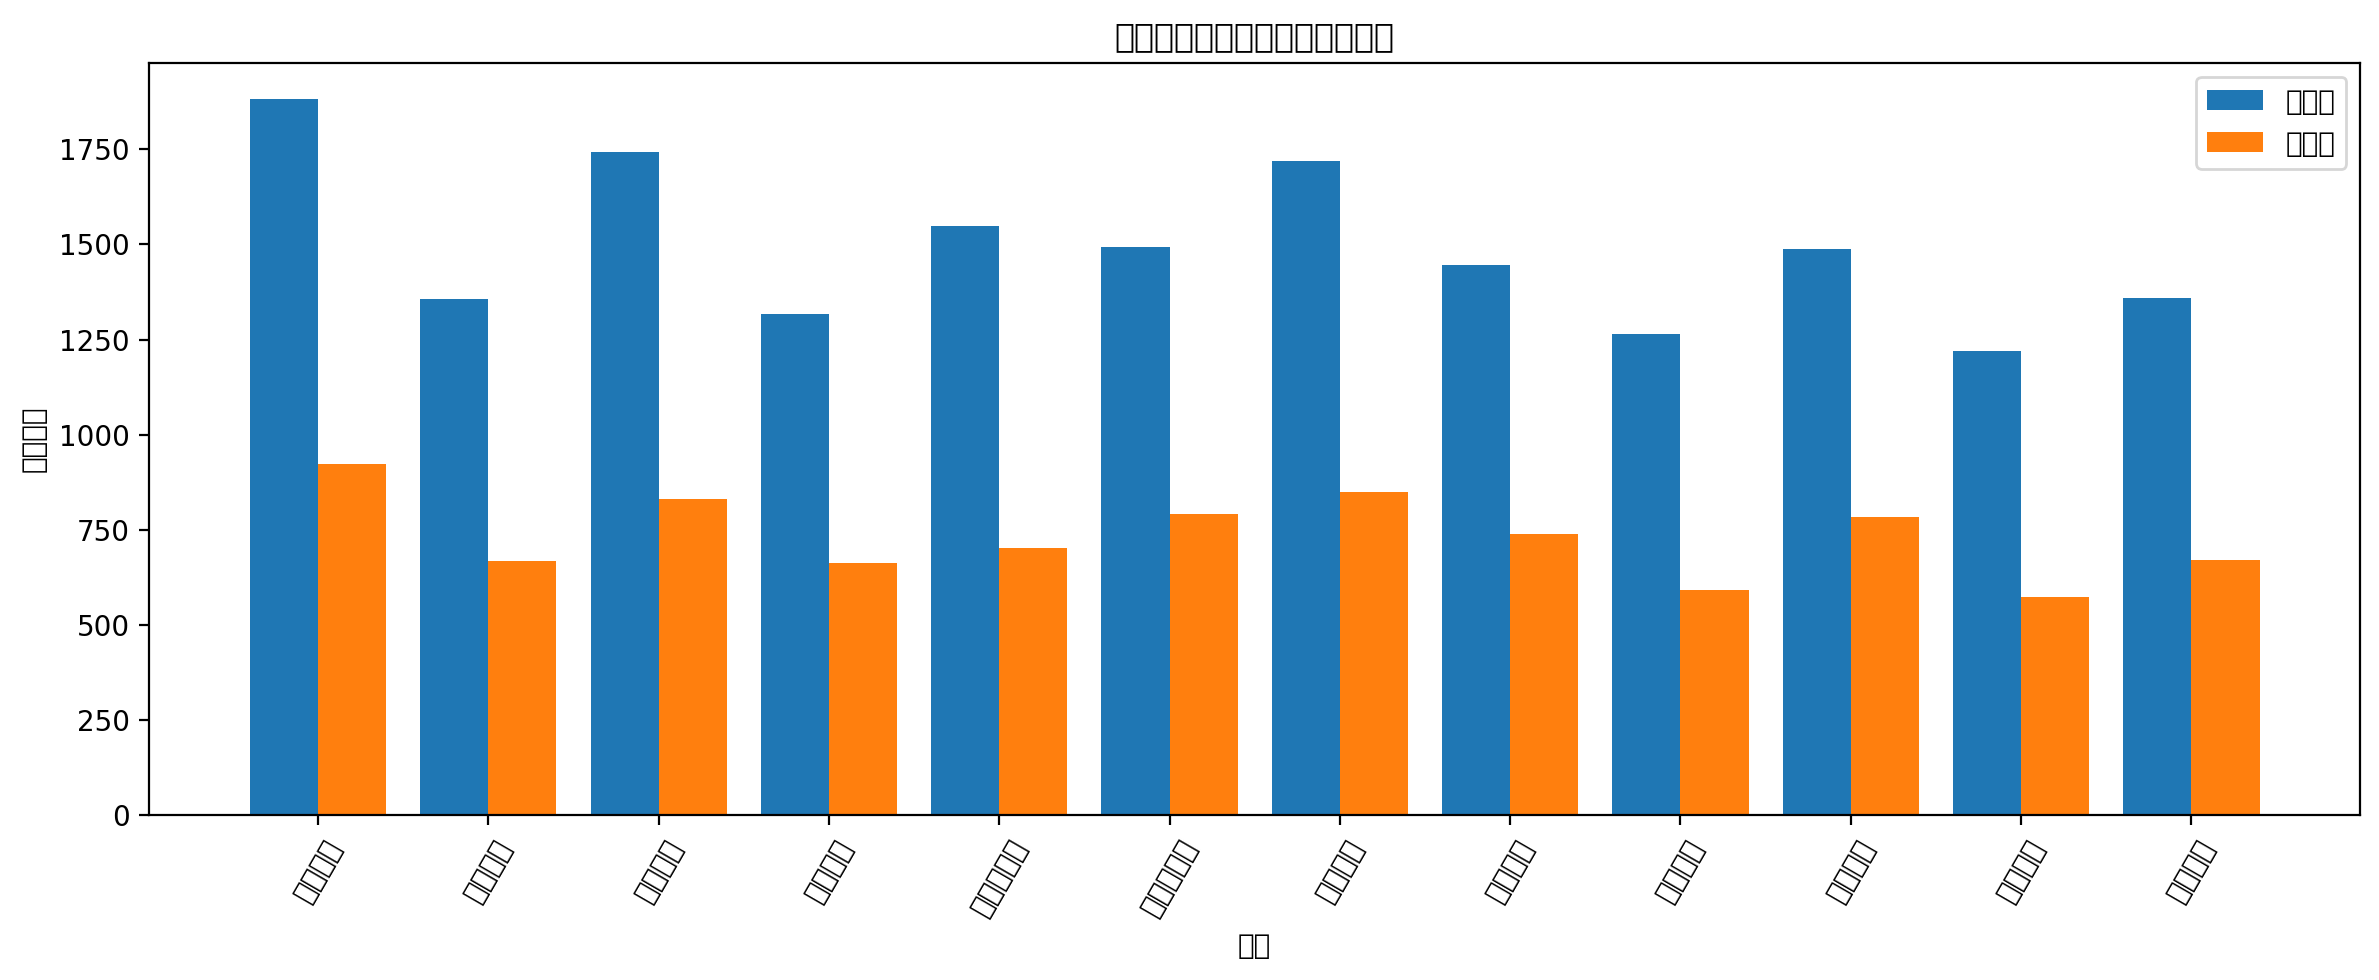

In [7]:
train_counts = np.bincount(datasets["train"]["y"], minlength=12)
test_counts = np.bincount(datasets["test"]["y"], minlength=12)
positions = np.arange(12)
width = 0.4

plt.figure(figsize=(12, 5), dpi=200)
plt.bar(positions - width / 2, train_counts, width, label="训练集")
plt.bar(positions + width / 2, test_counts, width, label="测试集")
plt.xticks(positions, [GESTURE_NAMES[i] for i in range(1, 13)], rotation=60)
plt.xlabel("动作")
plt.ylabel("窗口数量")
plt.title("训练集和测试集的动作窗口分布")
plt.legend()
plt.tight_layout()
plt.show()


## 7. 保存训练集、测试集和元数据

每个 NPZ 文件包含 `X`、`y`、`subject`、`repetition` 和 `start_sample`。本 Notebook 不进行滤波或标准化。

In [8]:
train_path = OUTPUT_DIR / "train.npz"
test_path = OUTPUT_DIR / "test.npz"
metadata_path = OUTPUT_DIR / "metadata.json"

np.savez_compressed(train_path, **datasets["train"])
np.savez_compressed(test_path, **datasets["test"])

metadata = {
    "dataset": "NinaPro DB5",
    "exercise": "A / E1",
    "sample_rate_hz": SAMPLE_RATE,
    "channels": N_CHANNELS,
    "window_ms": WINDOW_MS,
    "window_samples": WINDOW_SIZE,
    "stride_ms": STRIDE_MS,
    "stride_samples": STRIDE_SIZE,
    "subjects": list(SUBJECT_IDS),
    "train_repetitions": list(TRAIN_REPETITIONS),
    "test_repetitions": list(TEST_REPETITIONS),
    "rest_included": False,
    "normalized": False,
    "filtered_in_notebook": False,
    "X_layout": "[窗口数, 16 个通道, 40 个时间点]",
    "label_mapping": {
        str(raw_label - 1): {"raw_label": raw_label, "name_zh": GESTURE_NAMES[raw_label]}
        for raw_label in range(1, 13)
    },
    "outputs": {
        split: {
            "file": f"{split}.npz",
            "X_shape": list(dataset["X"].shape),
            "class_counts": np.bincount(dataset["y"], minlength=12).tolist(),
        }
        for split, dataset in datasets.items()
    },
}

with metadata_path.open("w", encoding="utf-8") as file_handle:
    json.dump(metadata, file_handle, ensure_ascii=False, indent=2)

print(f"训练集：{train_path}")
print(f"测试集：{test_path}")
print(f"元数据：{metadata_path}")


训练集：/root/autodl-tmp/NinaPro/ninapro_data/processed/exerciseA/slide_window/train.npz
测试集：/root/autodl-tmp/NinaPro/ninapro_data/processed/exerciseA/slide_window/test.npz
元数据：/root/autodl-tmp/NinaPro/ninapro_data/processed/exerciseA/slide_window/metadata.json


## 8. 重新加载并验证

保存后重新读取文件，检查形状、类型、标签和重复编号，避免把写盘问题带入训练阶段。

In [9]:
def validate_dataset(path, allowed_repetitions):
    """读取并验证一个滑动窗口数据文件。"""
    with np.load(path, allow_pickle=False) as loaded:
        expected_fields = {"X", "y", "subject", "repetition", "start_sample"}
        assert set(loaded.files) == expected_fields
        data = {name: loaded[name] for name in loaded.files}

    sample_count = len(data["X"])
    assert data["X"].shape[1:] == (N_CHANNELS, WINDOW_SIZE)
    assert data["X"].dtype == np.float32 and np.isfinite(data["X"]).all()
    assert data["y"].dtype == np.int64
    assert all(len(value) == sample_count for value in data.values())
    assert set(np.unique(data["y"])) == set(range(12))
    assert set(np.unique(data["subject"])) == set(SUBJECT_IDS)
    assert set(np.unique(data["repetition"])) == set(allowed_repetitions)
    return data


saved_train = validate_dataset(train_path, TRAIN_REPETITIONS)
saved_test = validate_dataset(test_path, TEST_REPETITIONS)

# 训练集和测试集使用不同的重复编号，这是避免窗口泄漏的关键检查。
assert set(np.unique(saved_train["repetition"])).isdisjoint(np.unique(saved_test["repetition"]))
print("验证通过。")
print("训练窗口数：", len(saved_train["X"]))
print("测试窗口数：", len(saved_test["X"]))
saved_train


验证通过。
训练窗口数： 17839
测试窗口数： 8787


{'X': array([[[  3.,   1.,   5., ...,  -2.,  -6.,  -1.],
         [  2.,   5.,   3., ..., -13., -16.,  16.],
         [ -1.,  -2.,   0., ...,  -3.,  -4.,  -1.],
         ...,
         [ -2.,  -1.,  -1., ...,  -3.,  -2.,  -1.],
         [ -5.,  -4.,  -4., ...,  -1.,  -4.,   0.],
         [ -2.,  -2.,  -4., ...,  -1.,  -2.,  -2.]],
 
        [[  8.,  -3.,  -4., ...,   1.,  -3.,  -6.],
         [  0.,  15., -17., ...,  10., -36., -26.],
         [ -5.,  -5.,  12., ...,  -3.,  -2.,   1.],
         ...,
         [ -5.,   1.,   0., ...,  -1.,   4.,  -1.],
         [ -3.,   0.,  -1., ...,   1.,   2.,  -3.],
         [ -3.,   0.,  -2., ...,   1.,  -1.,  -1.]],
 
        [[ 11., -12.,  -4., ..., -15.,  -1.,   6.],
         [  7., -13., -10., ..., -17., -15.,  44.],
         [  4.,  -5.,   0., ...,  -6.,  -8.,  11.],
         ...,
         [  3.,  -3.,  -2., ...,   1.,  -2.,  -6.],
         [  2.,  -9.,   1., ...,   1.,   3.,  -3.],
         [  1.,  -2.,  -4., ...,  -2.,   2.,   1.]],
 
        

## 9. PyTorch 读取示例（可选）

In [10]:
try:
    import torch

    with np.load(train_path, allow_pickle=False) as train_file:
        X_train = torch.from_numpy(train_file["X"])
        y_train = torch.from_numpy(train_file["y"])

    print("PyTorch 输入形状：", tuple(X_train.shape))
    print("PyTorch 标签形状：", tuple(y_train.shape))
except ModuleNotFoundError:
    print("当前环境未安装 PyTorch；前面的 NPZ 数据仍可正常使用。")


PyTorch 输入形状： (17839, 16, 40)
PyTorch 标签形状： (17839,)
